In [74]:
from topological_insulator import Problem
import numpy as np

In [75]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [ ]:
def _set_eigenvalues(self, problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * self.N_projections 
        parser["chadi_soc"][label_i]["Delta_pp"] = self.Delta_SOC
        parser["interaction"][label_i]["U_p"] = self.U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = self.t - self.delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = self.t + self.delta
            except:
                pass

In [77]:
location = "edge"
N_r = 20

In [ ]:
Delta_SOC = -5
t = -1
delta = 0.832
x1 = [0.00000000e+00, 0.00000000e+00, 5.30840492e-01, 5.31834308e-01,
       5.33583351e-01, 5.45436782e-01, 6.67338552e-01, 6.62723632e-01,
       9.48396691e-32, 9.33650185e-32, 5.29741543e-01, 5.41433511e-01,
       5.33626510e-01, 5.41243329e-01, 6.74129604e-01, 6.58294397e-01] # U = 1, n_h = 1

cases = {
    0: {"U": 1, "x":x1},
    # 1: {"U": 8} 
}

In [79]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t, delta, U)
    problem.setup(
        N_r = N_r,
        N_k = 200,
        location = location,
        BZ = "reduced",
        dangling_bonds=False
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -8.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [80]:
import numpy as np
edge_sites = [0, 1, -2, -1]
bands = [-1, -2]
a = N_r * 8
b = N_r * 16
j_3_2 = [i for i in range(a, b)]
threshold = 0.3

## Case 0

In [81]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

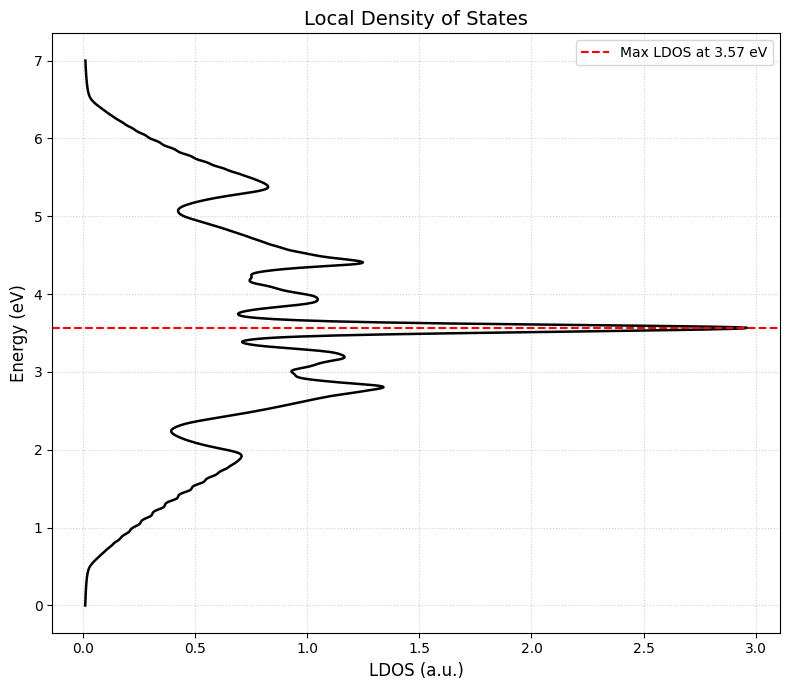

In [82]:
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 7, 
    E_min = 0,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS, E)

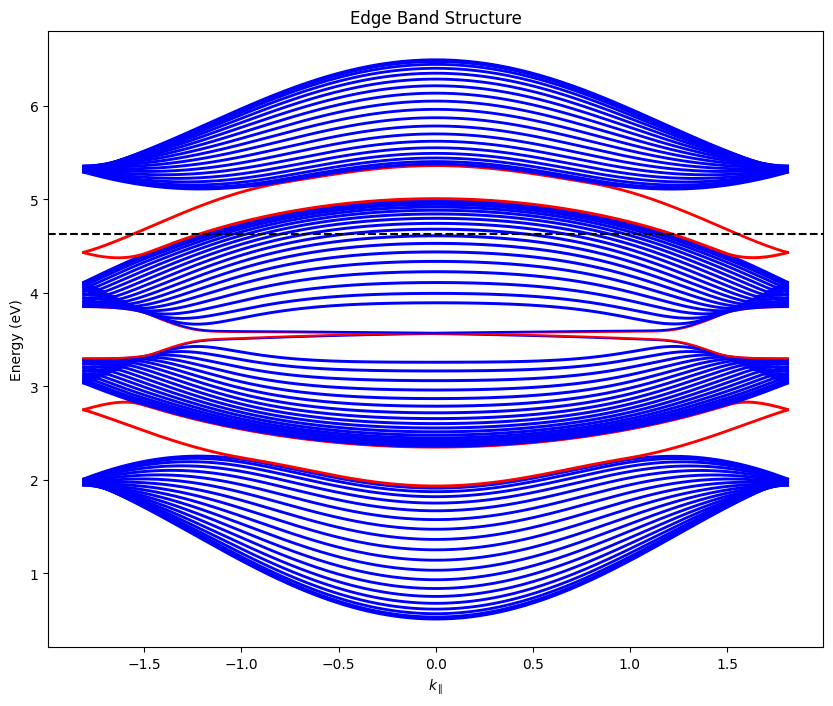

In [83]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands, mu = 4.63)

band idx: 198


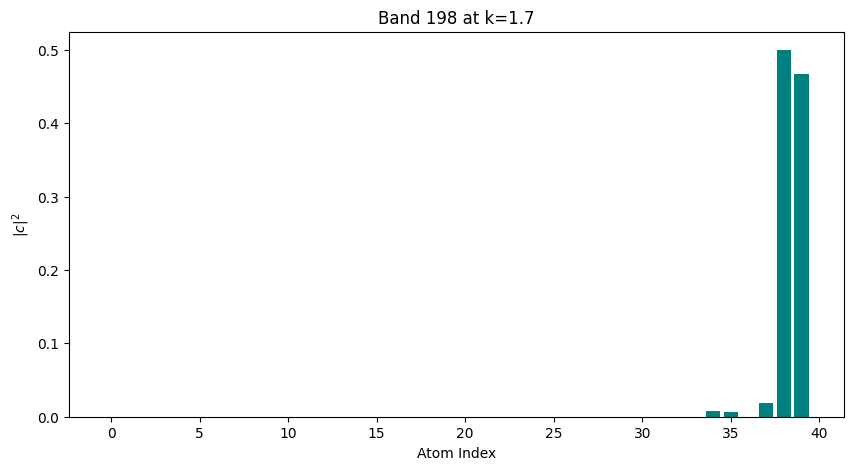

band idx: 199


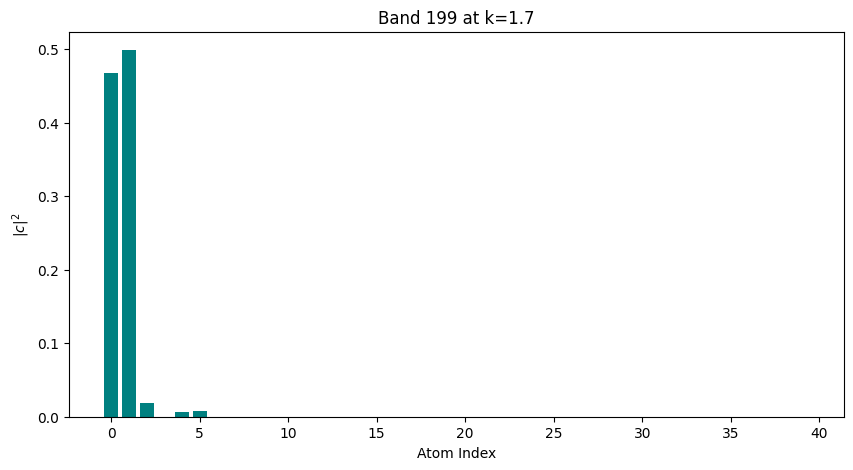

band idx: 200


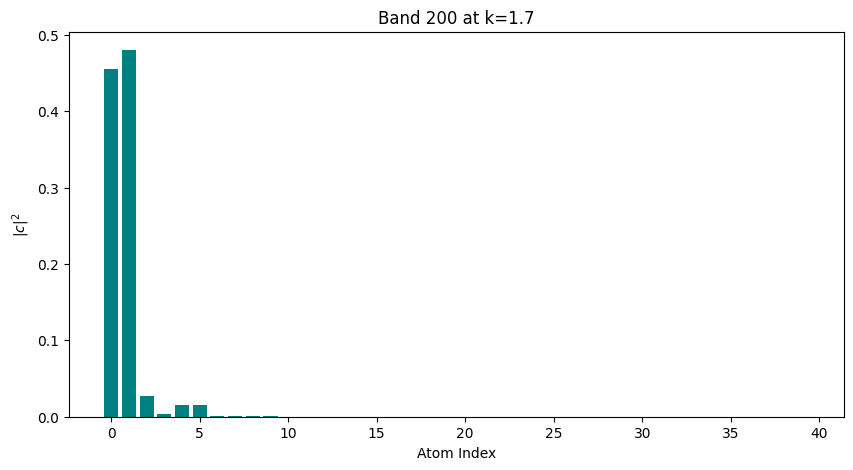

band idx: 201


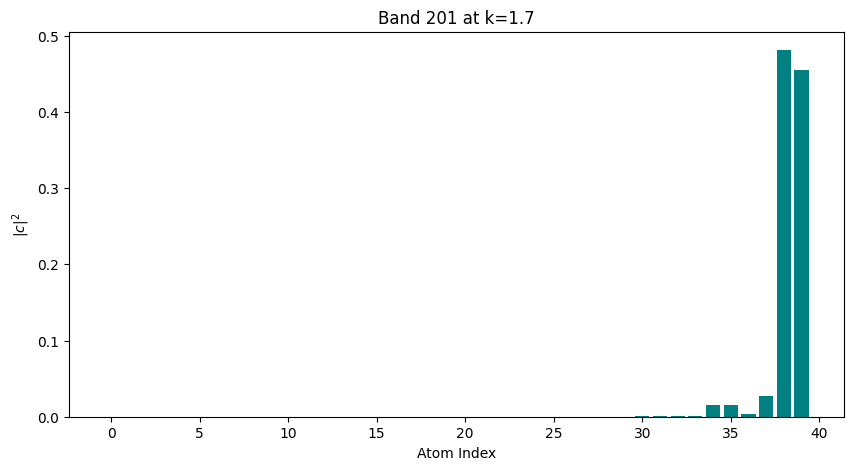

band idx: 239


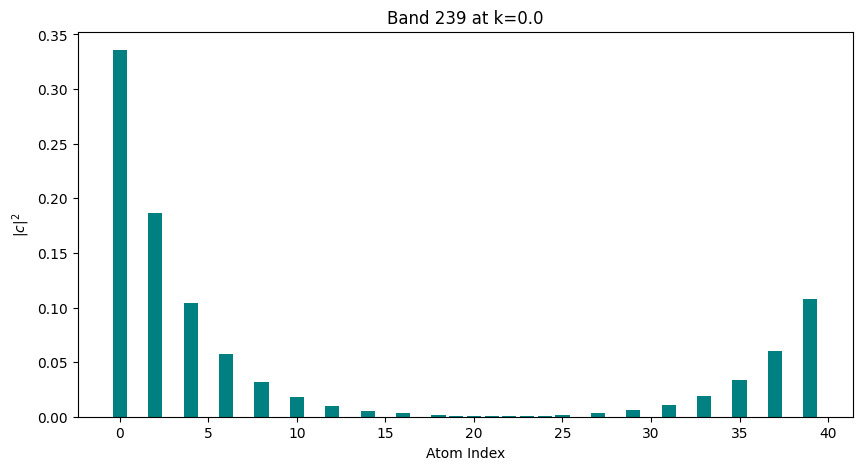

band idx: 240


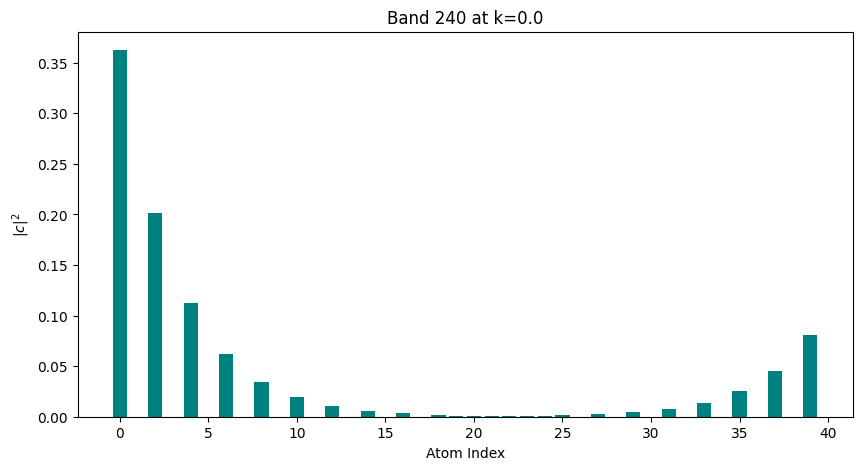

band idx: 278


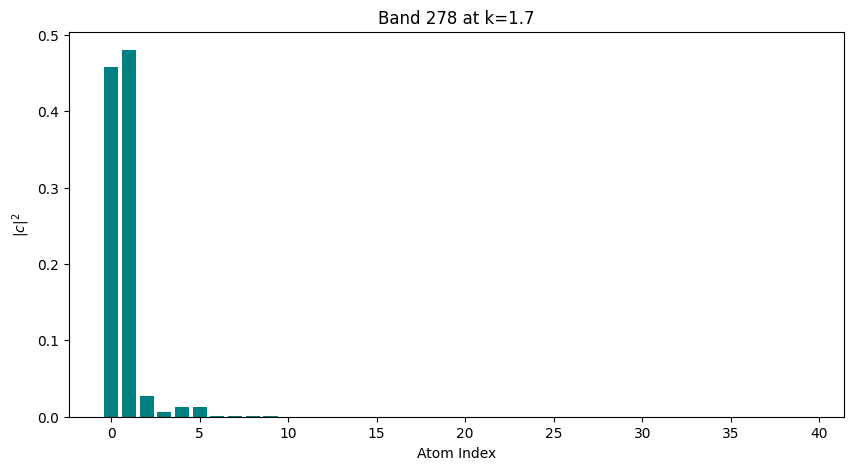

band idx: 279


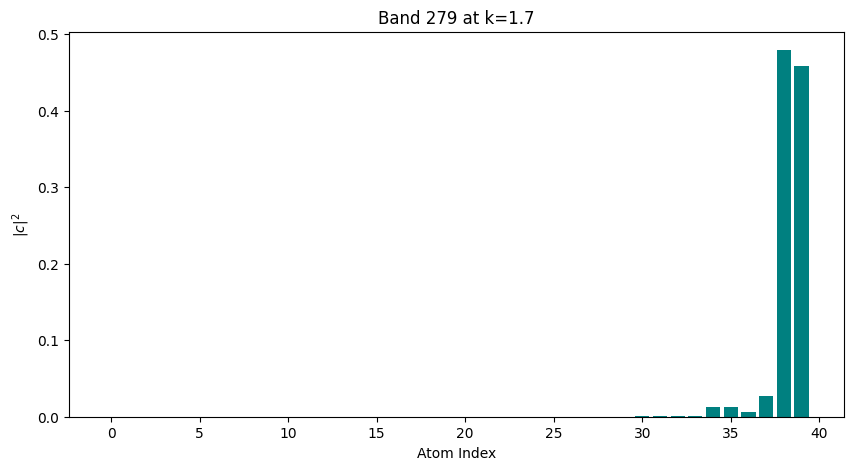

band idx: 280


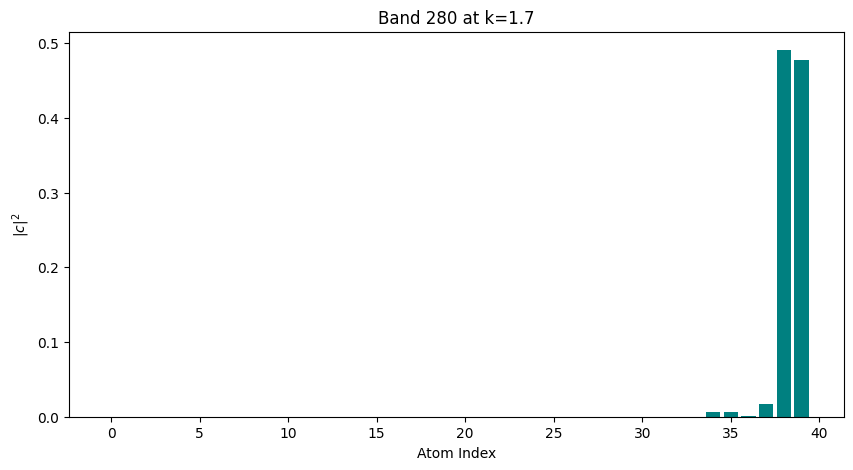

band idx: 281


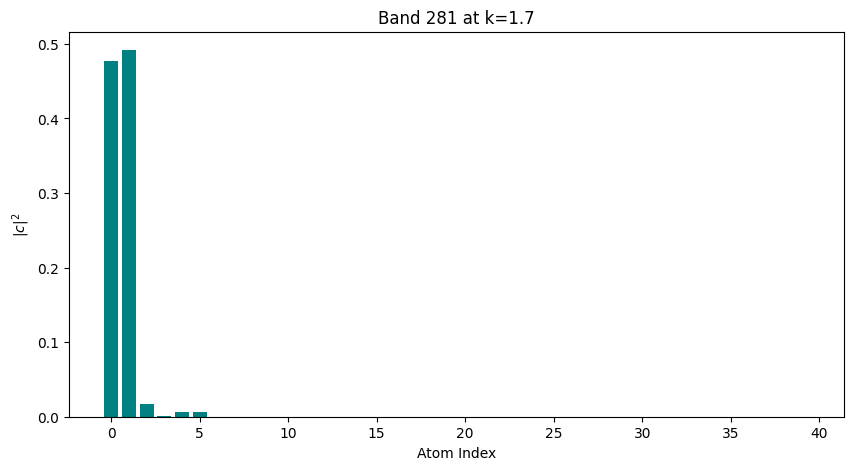

In [84]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -1.7
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 1.7
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()

## Case 1

In [85]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

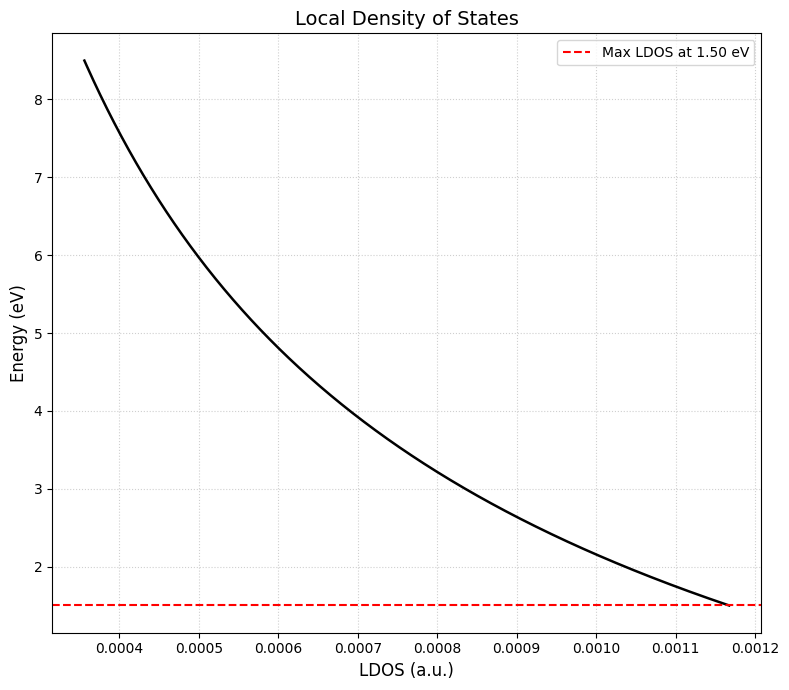

In [86]:
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS, E)

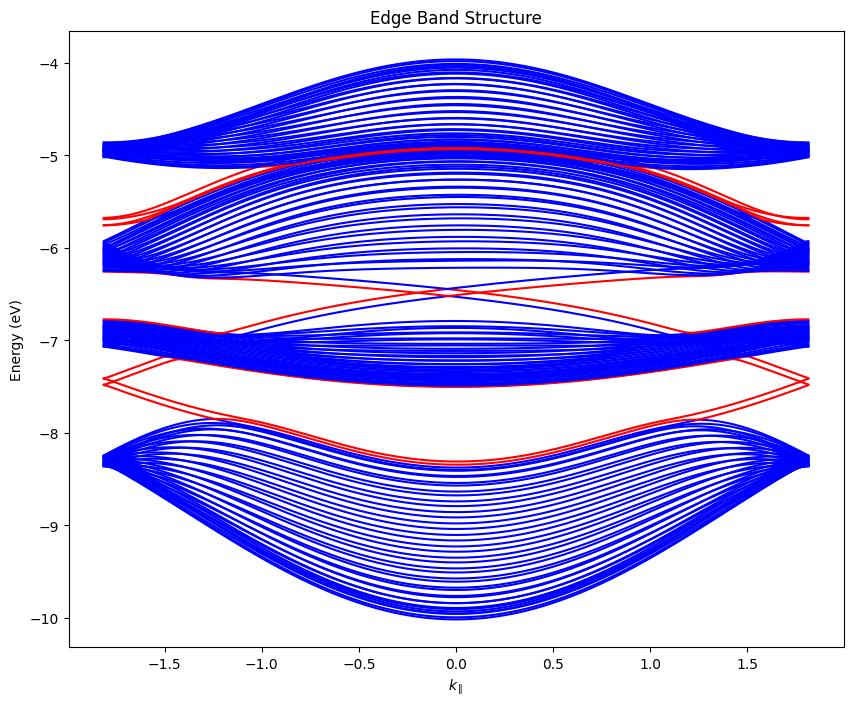

In [87]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

In [88]:
# N_projections = len(tb_edge.coupled_states)
# N_sites = len(tb_edge.sublattice_idxs)
# N_bands = N_sites * N_projections

# Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
# for band in edge_bands:
#     if band in edge_bands_0:
#         k_target = -1.7
#     elif band in edge_bands_1:
#         k_target = 0.0
#     else:
#         k_target = 1.7
#     if band < 100:
#         continue
#     k_idx = np.argmin(np.abs(g.k_edge - k_target))
#     Psi_k = Psi_dict[band][k_idx, :]
#     total_norm = np.sum(np.abs(Psi_k)**2)
#     print(f"band idx: {band}")
#     n_atoms = len(tb_edge.sublattice_idxs)
#     atomic_wavefunctions = {}
#     atom_contributions = np.zeros(n_atoms)
#     for i in range(n_atoms):
#         start = i * N_projections
#         end = start + N_projections
#         orbital_block = Psi_k[start:end]  # Orbitals for atom i
#         atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
#         atomic_wavefunctions[i] = Psi_k[start:end] 

#     from matplotlib import pyplot as plt
#     plt.figure(figsize=(10, 5))
#     plt.bar(range(n_atoms), atom_contributions, color='teal')
#     plt.xlabel("Atom Index")
#     plt.ylabel(f"$|c|^2$")
#     # plt.xlim(0, 10)
#     plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
#     plt.show()